# LED Calib for Commissioning of 2x2 run2


In [1]:
%load_ext autoreload

%autoreload 2

from calibWvfms import *

Don't forget to activate the ndlar-flow venv :)

In [2]:
# Directory
d = '/Users/nsallin/develop/data/2x2/flow/LEDcalib/'
# /global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v02_LEDscan/mpd_run_calib_rctl_1923.FLOW.hdf5

# File
f = 'mpd_run_calib_rctl_1923.FLOW.hdf5'


run_summary = '/Users/nsallin/develop/data/2x2/2x2_calib/LEDcalib_run2/20251008_200916_run_summary.json'

# Output
o ='/Users/nsallin/develop/data/2x2/2x2_calib/LEDcalib_run2/test'

In [3]:
# Load the file
wvfms = calibWvfms(filedir = d, filename = f, output_path=o, log_level='DEBUG')

2025-10-13 21:47:19,610 - INFO - set_log_level - Log level changed to DEBUG
2025-10-13 21:47:26,211 - INFO - __init__ - Processing file /Users/nsallin/develop/data/2x2/flow/LEDcalib/mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-13 21:47:26,223 - INFO - __init__ - The output path is set to /Users/nsallin/develop/data/2x2/2x2_calib/LEDcalib_run2/test
2025-10-13 21:47:26,224 - INFO - __init__ - Number of events in the selection: 19912


In [4]:
import json

def get_subruns_and_channels(json_path):
    """
    Extract 'data_file', 'subrun' and 'active_chans' values from a JSON file.

    Parameters:
        json_path (str): Path to the JSON file.

    Returns:
    subruns_info (list): subrun infos of the type [[data_file, subrun_number, active_chans], ...] with
            - data_file (str): path to data file
            - subrun_number (int): subrun number
            - active_chans (list) : list of active chans of the type [[adcA, chanB], [adcX, chanY], ...]

    """
    with open(json_path, "r") as f:
        run_info = json.load(f)

    subruns_info = []

    if "subruns" in run_info:
        for subrun in run_info["subruns"]:
            # print(subrun)
            data_file = subrun["data_file"]
            subrun_number = subrun["subrun"]
            active_chans = subrun["active_chans"]

            subruns_info.append([data_file, subrun_number, active_chans])
    else:
        raise KeyError(f"'subruns' key not found in {json_path}")

    return subruns_info

In [5]:
run_info = get_subruns_and_channels(run_summary)

subrun = 0

active_chans = run_info[subrun][2]

# print("~~~~~~~~~~~~ run ~~~~~~~~~~~~")
# print(f"file  :{}")

print("~~~~~~~~~~~~ subrun ~~~~~~~~~~~~")
print(f"file  :{run_info[subrun][0]}")
print(f"subrun  :{run_info[subrun][1]}")
print(f"active_chans ({len(active_chans)}): {active_chans}")

~~~~~~~~~~~~ subrun ~~~~~~~~~~~~
file  :/data/LRS_run2/cold_commission/v02_LEDscan/mpd_run_calib_rctl_1923.data
subrun  :0
active_chans (37): [[0, 4], [0, 5], [0, 8], [0, 9], [0, 36], [0, 37], [3, 4], [3, 5], [3, 36], [3, 37], [4, 10], [4, 11], [4, 12], [4, 13], [4, 14], [4, 26], [4, 27], [4, 28], [4, 29], [4, 30], [4, 31], [4, 60], [4, 61], [4, 62], [4, 63], [6, 6], [6, 7], [6, 38], [6, 39], [6, 54], [6, 55], [7, 6], [7, 7], [7, 38], [7, 39], [7, 54], [7, 55]]


In [6]:
import matplotlib.pyplot as plt

def title_page(text, output):
    # Create a figure with a black background
    fig, ax = plt.subplots(figsize=(6, 4))
    # ax.set_facecolor('black')

    # Add centered white text
    ax.text(0.5, 0.5, text, color='black',
            fontsize=24, ha='center', va='center')

    # Remove axes
    ax.axis('off')

    # Save to PDF
    
    output.savefig()
    plt.close()

In [11]:
import os

def calibrate_sipm(wfms):
    """
        Function to run through the calibration chain 
            1. Compute the fingerplots
            # 2. Fit the fingerplots
            # 3. Compute the gain
            # 4. Print out the result in a summary pdf

        Summary pdf is made of:
            - 10 waveforms (equally spaced between the first and last events)
            - the fingerplot
            # - the fingerplot with the inital guess and the fitted funciton
            - the wvfms that didnt't make the "int extrem value cut"
    """
    # ~~~~~~~~~~~~~~~~~~ Define general constants ~~~~~~~~~~~~~~~~~~
    signal_window = [60,90] # [ticks]
    Nevents = 19_000
    # ~~~~~~~~~~~~~~~~~~ Loop over the adc and chan (w.r.t the run summary) ~~~~~~~~~~~~~~~~~~
    for adc, chan in active_chans:

        # adc = 4   #DEBUG
        # chan = 13

        output_dir = os.path.join(wvfms.output_path, f"{adc}/{chan}")
        os.makedirs(output_dir, exist_ok=True)
        output_pdf = os.path.join(output_dir, "calib_summary.pdf")

        # Output file
        with PdfPages(output_pdf) as summary_pdf:


            print(f" adc: {adc}, chan: {chan}") # DEBUG

            # ~~~~~~~~~~~~~~~~~~ Compute the fingerplot ~~~~~~~~~~~~~~~~~~
            wvfms.compute_fingerplots(Nevent=Nevents, adcs=adc, chans=chan, int_window=signal_window, Nbins=110, mode='integral', nSig=5)
            # Save in output pdf
            title_page("Finger plot",summary_pdf)
            plot_fingerplot(*wvfms.fingerplots[adc][chan], title=f'Fingerplot of ADC {adc}, chan. {chan}', output=summary_pdf)# show=True, plot_name=f'fingerplot_ADC{adc}_chan{chan}.png')

            # ~~~~~~~~~~~~~~~~~~ Fit the fingerplot ~~~~~~~~~~~~~~~~~~
            title_page("Finger plot with p0",summary_pdf)
            wvfms.fit_fingerplots(adc, chan, output=summary_pdf)

            # ~~~~~~~~~~~~~~~~~~ Compute the gain ~~~~~~~~~~~~~~~~~~
            wvfms.compute_gains(adcs=adc, chans=chan)

            # Save in output pdf
            title_page("Finger plot with fitted function and gain",summary_pdf)
            print(f" in notebook: adc: {adc}, chan: {chan}, status: {wvfms.fit_status[adc][chan]}") # DEBUG
            plot_fingerplot(*wvfms.fingerplots[adc][chan], title=f'Fingerplot of ADC {adc}, chan. {chan} with fitted function', fit_xlim=wvfms.fit_lim[adc][chan], fit_params=wvfms.fitted_params[adc][chan], output=summary_pdf, fit_status=wvfms.fit_status[adc][chan], reduced_chi_squared=wvfms.reduced_chi_squared[adc][chan], gain=wvfms.gains[adc][chan])
            



            # ~~~~~~~~~~~~~~~~~~ Print out summary ~~~~~~~~~~~~~~~~~~

            # Print some waveforms for examples
            title_page("Wvfms Examples",summary_pdf)
            Nwvfms = 10
            for event in range(0, Nevents, int(Nevents/Nwvfms)):
                wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)


            # Extrem waveforms
            title_page("Cutout waveforms Examples:\n(Integral more than\n5 sig from mean integral value)",summary_pdf)
            print(f" extrem events: {wvfms.extrem_Int_val[adc][chan]}")
            for event in wvfms.extrem_Int_val[adc][chan]:
                wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)

        # break # DEBUG



In [12]:
calibrate_sipm(wvfms)

2025-10-13 21:48:44,081 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5 with 19000 events
2025-10-13 21:48:44,083 - DEBUG - compute_fingerplots - ADCs: [0]
2025-10-13 21:48:44,084 - DEBUG - compute_fingerplots - Chans: [4]
2025-10-13 21:48:44,144 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-13 21:48:44,150 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:48:44,205 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-13 21:48:44,206 - DEBUG - fit_fingerplots - ADCs: [0]
2025-10-13 21:48:44,206 - DEBUG - fit_fingerplots - Chans: [4]
2025-10-13 21:48:44,206 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 0, chan. 4
2025-10-13 21:48:44,207 - DEBUG - plot_fingerplot - Plotting the finger plot


 adc: 0, chan: 4
shape: (19100,)
fit_bounds: [[ 9.00600000e+02 -8.78415691e+05  1.34214894e+02  1.74000000e+02
  -8.78195109e+05  1.34214894e+02  5.51000000e+02 -8.77790709e+05
   1.09525000e+02  1.29600000e+02 -8.77606891e+05  1.09525000e+02
   2.32750000e+02 -8.77312782e+05  4.20464782e+01  7.32000000e+01
  -8.77128964e+05  4.20464782e+01]
 [ 1.04380000e+03 -8.78342164e+05  3.36537236e+02  3.20000000e+02
  -8.78084818e+05  8.39843089e+02  6.39000000e+02 -8.77717182e+05
   2.74812500e+02  2.38600000e+02 -8.77496600e+05  6.85531250e+02
   2.70500000e+02 -8.77239255e+05  1.06116196e+02  1.35200000e+02
  -8.77018673e+05  2.63790489e+02]]
fit_p0: [ 9.48000000e+02 -8.78378927e+05  1.67768618e+02  2.90000000e+02
 -8.78158345e+05  1.67768618e+02  5.80000000e+02 -8.77753945e+05
  1.36906250e+02  2.16000000e+02 -8.77570127e+05  1.36906250e+02
  2.45000000e+02 -8.77276018e+05  5.25580978e+01  1.22000000e+02
 -8.77092200e+05  5.25580978e+01]



status: None
sigma: [15.96871942 20.66397832 25.278

2025-10-13 21:48:44,283 - DEBUG - fit_fingerplots - Fingerplots of ADC 0, chan. 4 fitted
2025-10-13 21:48:44,284 - INFO - fit_fingerplots - The fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5 were fitted.
2025-10-13 21:48:44,289 - DEBUG - plot_fingerplot - Plotting the finger plot


 in notebook: adc: 0, chan: 4, status: 0



status: 0
 extrem events: [ 1376  1957  2213  3068  3603  4028  5877  6152  7293  7880 10604 10778
 13207 15200 16159 17181 17221 17777 18682]


2025-10-13 21:48:45,354 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5 with 19000 events
2025-10-13 21:48:45,355 - DEBUG - compute_fingerplots - ADCs: [0]
2025-10-13 21:48:45,355 - DEBUG - compute_fingerplots - Chans: [5]
2025-10-13 21:48:45,359 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-13 21:48:45,400 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:48:45,463 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-13 21:48:45,464 - DEBUG - fit_fingerplots - ADCs: [0]
2025-10-13 21:48:45,464 - DEBUG - fit_fingerplots - Chans: [5]
2025-10-13 21:48:45,464 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 0, chan. 5
2025-10-13 21:48:45,465 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:48:45,533 - DEBUG - fit_fingerplots - Fingerplots of ADC 0, chan. 5 fitted
2025-10-13 21:4

...

 adc: 7, chan: 54


2025-10-13 21:49:32,122 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-13 21:49:32,127 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:49:32,191 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-13 21:49:32,191 - DEBUG - fit_fingerplots - ADCs: [7]
2025-10-13 21:49:32,192 - DEBUG - fit_fingerplots - Chans: [54]
2025-10-13 21:49:32,192 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 7, chan. 54
2025-10-13 21:49:32,193 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:49:32,283 - DEBUG - fit_fingerplots - Fingerplots of ADC 7, chan. 54 fitted
2025-10-13 21:49:32,284 - INFO - fit_fingerplots - The fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5 were fitted.
2025-10-13 21:49:32,288 - DEBUG - plot_fingerplot - Plotting the finger plot


shape: (19100,)
fit_bounds: [[ 1.49910000e+03 -8.25265364e+05  1.70685617e+02  6.00000000e-01
  -8.24544345e+05  1.70685617e+02  1.86200000e+03 -8.23282564e+05
   1.87713109e+02  6.18000000e+01 -8.22561545e+05  1.87713109e+02
   1.16090000e+03 -8.21299764e+05  1.99372902e+02  1.46400000e+02
  -8.20578745e+05  1.99372902e+02  5.31050000e+02 -8.19136709e+05
   2.70997322e+02  8.46000000e+01 -8.18415691e+05  2.70997322e+02
   2.39400000e+02 -8.17153909e+05  2.64502167e+02  4.92000000e+01
  -8.16432891e+05  2.64502167e+02]
 [ 1.73680000e+03 -8.24904855e+05  4.27714043e+02  2.10000000e+00
  -8.24003582e+05  1.06778511e+03  2.15700000e+03 -8.22922055e+05
   4.70282772e+02  1.14300000e+02 -8.22020782e+05  1.17420693e+03
   1.34520000e+03 -8.20939255e+05  4.99432256e+02  2.69400000e+02
  -8.20037982e+05  1.24708064e+03  6.15900000e+02 -8.18776200e+05
   6.78493304e+02  1.56100000e+02 -8.17874927e+05  1.69473326e+03
   2.78200000e+02 -8.16793400e+05  6.62255418e+02  9.12000000e+01
  -8.15892127

2025-10-13 21:49:32,922 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5 with 19000 events
2025-10-13 21:49:32,922 - DEBUG - compute_fingerplots - ADCs: [7]
2025-10-13 21:49:32,922 - DEBUG - compute_fingerplots - Chans: [55]
2025-10-13 21:49:32,925 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-13 21:49:32,929 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:49:32,988 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-13 21:49:32,989 - DEBUG - fit_fingerplots - ADCs: [7]
2025-10-13 21:49:32,989 - DEBUG - fit_fingerplots - Chans: [55]
2025-10-13 21:49:32,989 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 7, chan. 55
2025-10-13 21:49:32,990 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-13 21:49:33,073 - DEBUG - fit_fingerplots - Fingerplots of ADC 7, chan. 55 fitted
2025-10-13 

 adc: 7, chan: 55
shape: (19100,)
fit_bounds: [[ 1.93705000e+03 -8.30336091e+05  1.39903429e+02  6.00000000e-01
  -8.29547000e+05  1.39903429e+02  1.93230000e+03 -8.28166091e+05
   1.81585113e+02  1.12200000e+02 -8.27377000e+05  1.81585113e+02
   1.09535000e+03 -8.25996091e+05  2.20974890e+02  1.69200000e+02
  -8.25207000e+05  2.20974890e+02  4.56000000e+02 -8.23826091e+05
   3.25990822e+02  1.21800000e+02 -8.23037000e+05  3.25990822e+02
   1.88100000e+02 -8.21458818e+05  4.13684013e+02  7.14000000e+01
  -8.20669727e+05  4.13684013e+02]
 [ 2.24390000e+03 -8.29941545e+05  3.50758572e+02  2.10000000e+00
  -8.28955182e+05  8.75396430e+02  2.23840000e+03 -8.27771545e+05
   4.54962783e+02  2.06700000e+02 -8.26785182e+05  1.13590696e+03
   1.26930000e+03 -8.25601545e+05  5.53437225e+02  3.11200000e+02
  -8.24615182e+05  1.38209306e+03  5.29000000e+02 -8.23431545e+05
   8.15977055e+02  2.24300000e+02 -8.22445182e+05  2.03844264e+03
   2.18800000e+02 -8.21064273e+05  1.03521003e+03  1.31900000

In [ ]:
len(wvfms.fit_status[wvfms.fit_status==1])

0

In [13]:
wvfms.gains

array([[0.00000000e+000, 4.94065646e-322, 0.00000000e+000,
        4.94065646e-322, 5.18806810e+002, 5.60897374e+002,
        0.00000000e+000, 0.00000000e+000, 4.80695261e+002,
        5.82424050e+002, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        4.97997625e+002, 5.01144882e+002, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+00

In [25]:
def plot_gain(gains):
    Nadcs, Nchans = gains.shape

    fig_gains, axs_gains = plt.subplots(nrows = 8, ncols=1, sharex='row', figsize=[12.8, 24])

    

    # colors=['red', 'blue', 'green', 'magenta']

    for adc, ax_gain in enumerate(axs_gains):
        ax_gain.set_xlabel('channel')
        ax_gain.set_ylabel('Gain [ADC counts]')
        ax_gain.grid(True)
        chans = np.arange(Nchans)   
        ax_gain.set_title(f"ADC: {adc}") 
        ax_gain.plot(chans, gains[adc], marker='.', ls='')
        ax_gain.set_xticks(np.arange(0, Nchans, 2))

    plt.tight_layout(pad=2.0)
                
    return 0


0

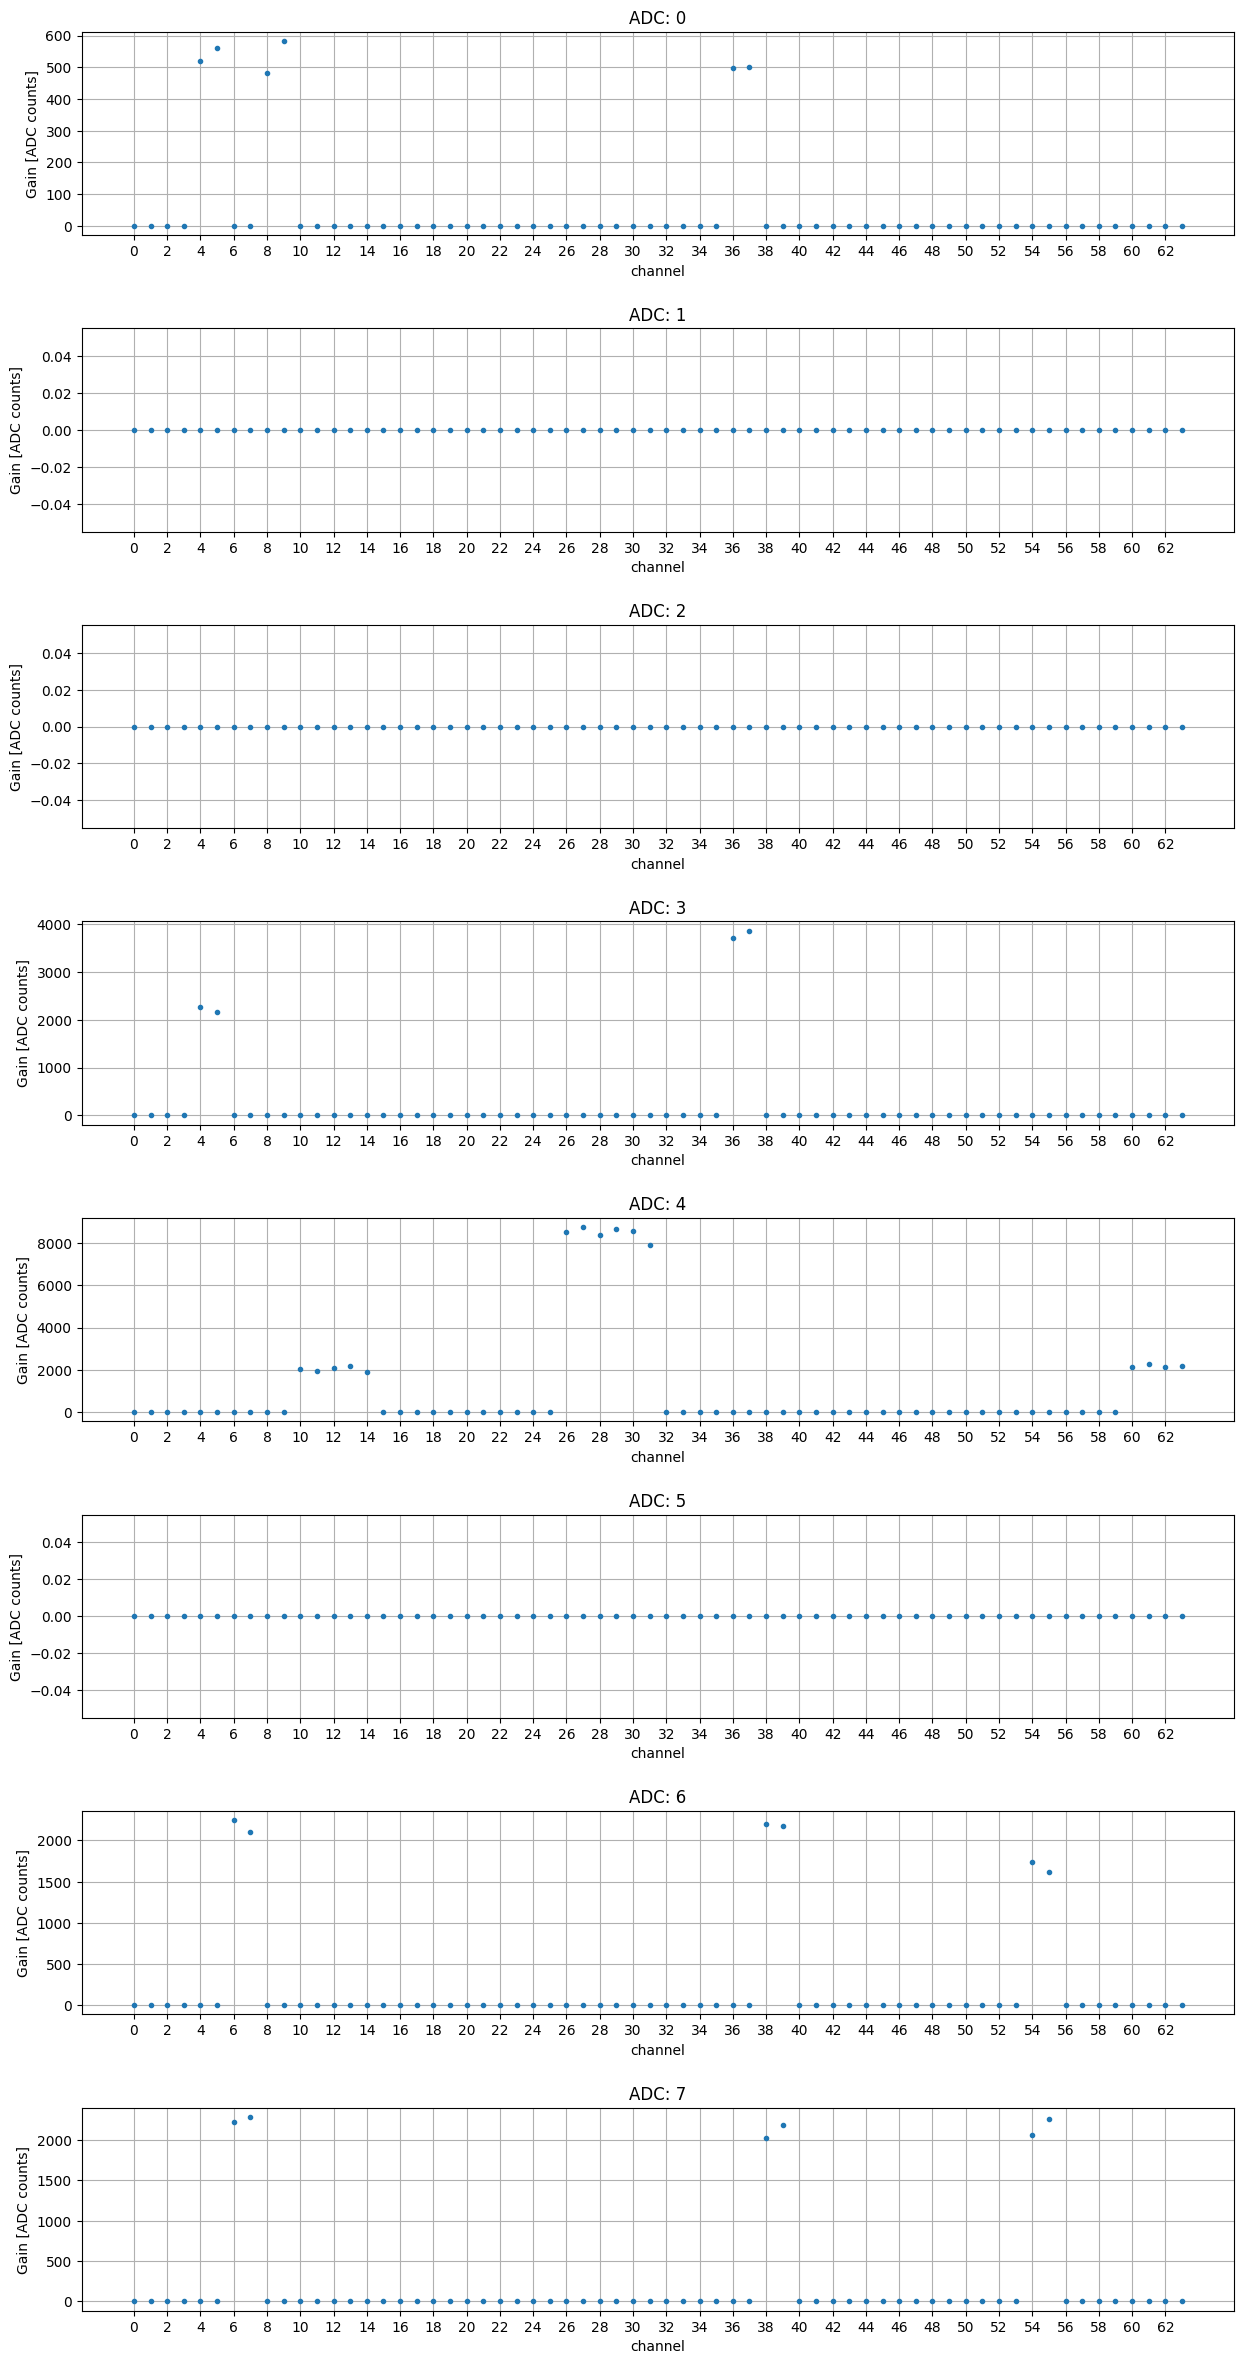

In [26]:
plot_gain(wvfms.gains)
